In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
print(df.columns.tolist())
print(df.shape)

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
(55500, 15)


In [4]:
## Exploring

In [5]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [7]:
print(df.describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [8]:
##  Cleaning

In [9]:
##  Remove negative billing amounts

df = df[df['Billing Amount'] > 0]
print(df.shape)

(55392, 15)


In [10]:
##   Converting dates to proper format

df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
print(df[['Date of Admission', 'Discharge Date']].head())

  Date of Admission Discharge Date
0        2024-01-31     2024-02-02
1        2019-08-20     2019-08-26
2        2022-09-22     2022-10-07
3        2020-11-18     2020-12-18
4        2022-09-19     2022-10-09


In [13]:
##  Calculating length of stay

df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
print(df['Length of Stay'].head())

0     2
1     6
2    15
3    30
4    20
Name: Length of Stay, dtype: int64


In [14]:
## Extracting year and month from admission date

df['Year'] = df['Date of Admission'].dt.year
df['Month'] = df['Date of Admission'].dt.month
print(df[['Date of Admission', 'Year', 'Month']].head())

  Date of Admission  Year  Month
0        2024-01-31  2024      1
1        2019-08-20  2019      8
2        2022-09-22  2022      9
3        2020-11-18  2020     11
4        2022-09-19  2022      9


In [15]:
##  Confirm everything is clean

print(df.isnull().sum())
print(df.shape)

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
Year                  0
Month                 0
dtype: int64
(55392, 18)


In [16]:
##   analyzing the data

In [17]:
##  Total patients admitted

total_patients = len(df)
print(f'Total Patients: {total_patients:,}')

Total Patients: 55,392


In [18]:
##  Most common medical conditions

conditions = df['Medical Condition'].value_counts()
print(conditions)

Medical Condition
Arthritis       9297
Diabetes        9284
Hypertension    9224
Obesity         9212
Cancer          9208
Asthma          9167
Name: count, dtype: int64


In [19]:
##   Average billing amount

avg_billing = df['Billing Amount'].mean()
print(f'Average Billing Amount: ${avg_billing:,.2f}')

Average Billing Amount: $25,590.08


In [20]:
##  Gender breakdown

gender = df['Gender'].value_counts()
print(gender)

Gender
Male      27726
Female    27666
Name: count, dtype: int64


In [21]:
##   Most common blood types

blood_types = df['Blood Type'].value_counts()
print(blood_types)

Blood Type
A-     6953
A+     6939
AB+    6937
B+     6936
B-     6933
AB-    6929
O+     6905
O-     6860
Name: count, dtype: int64


In [22]:
##   Average length of stay

avg_stay = df['Length of Stay'].mean()
print(f'Average Length of Stay: {avg_stay:.1f} days')

Average Length of Stay: 15.5 days


In [23]:
##   Most common admission types

admission_types = df['Admission Type'].value_counts()
print(admission_types)

Admission Type
Elective     18618
Urgent       18538
Emergency    18236
Name: count, dtype: int64


In [24]:
##  Top 10 hospitals by number of patients

top_hospitals = df['Hospital'].value_counts().head(10)
print(top_hospitals)

Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    38
Smith Ltd      37
Smith PLC      36
Smith Inc      34
Smith Group    34
Johnson Inc    33
Group Smith    32
Smith LLC      32
Name: count, dtype: int64


In [25]:
##  Most common medications

medications = df['Medication'].value_counts()
print(medications)

Medication
Lipitor        11119
Ibuprofen      11106
Aspirin        11073
Paracetamol    11050
Penicillin     11044
Name: count, dtype: int64


In [26]:
##  Test results breakdown

test_results = df['Test Results'].value_counts()
print(test_results)

Test Results
Abnormal        18589
Normal          18488
Inconclusive    18315
Name: count, dtype: int64


In [27]:
## Visualization

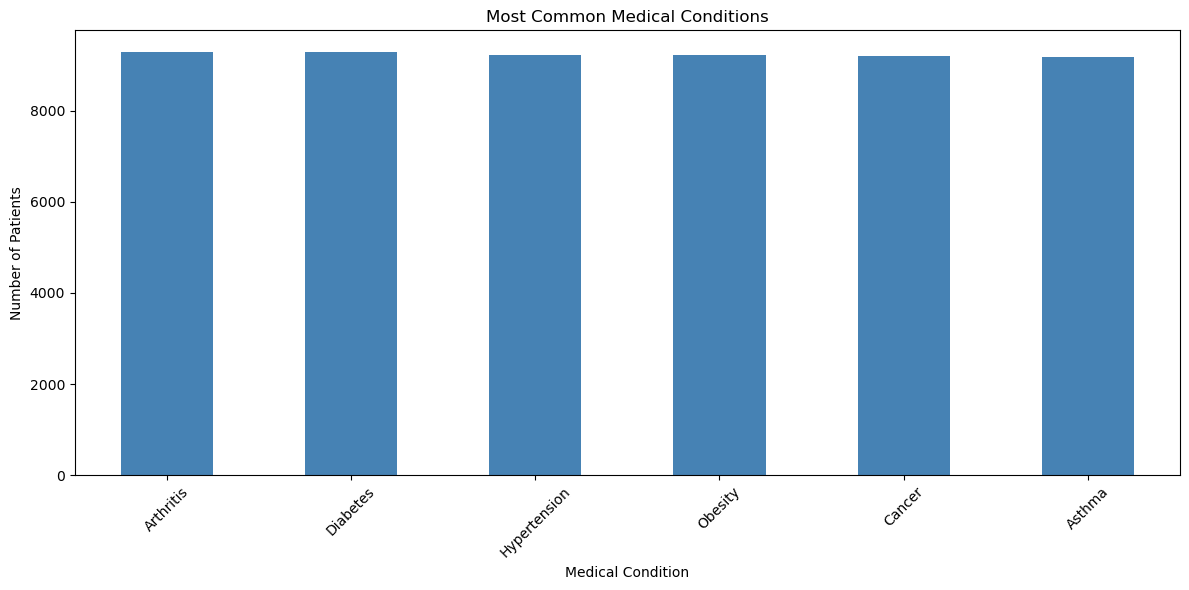

In [28]:
##   Most Common Medical Conditions (Bar Chart)

plt.figure(figsize=(12,6))
conditions.plot(kind='bar', color='steelblue')
plt.title('Most Common Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

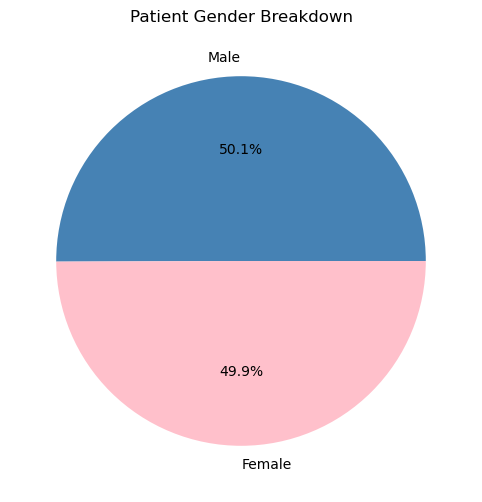

In [29]:
##   Gender Breakdown (Pie Chart)

plt.figure(figsize=(8,6))
gender.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'pink'])
plt.title('Patient Gender Breakdown')
plt.ylabel('')
plt.show()

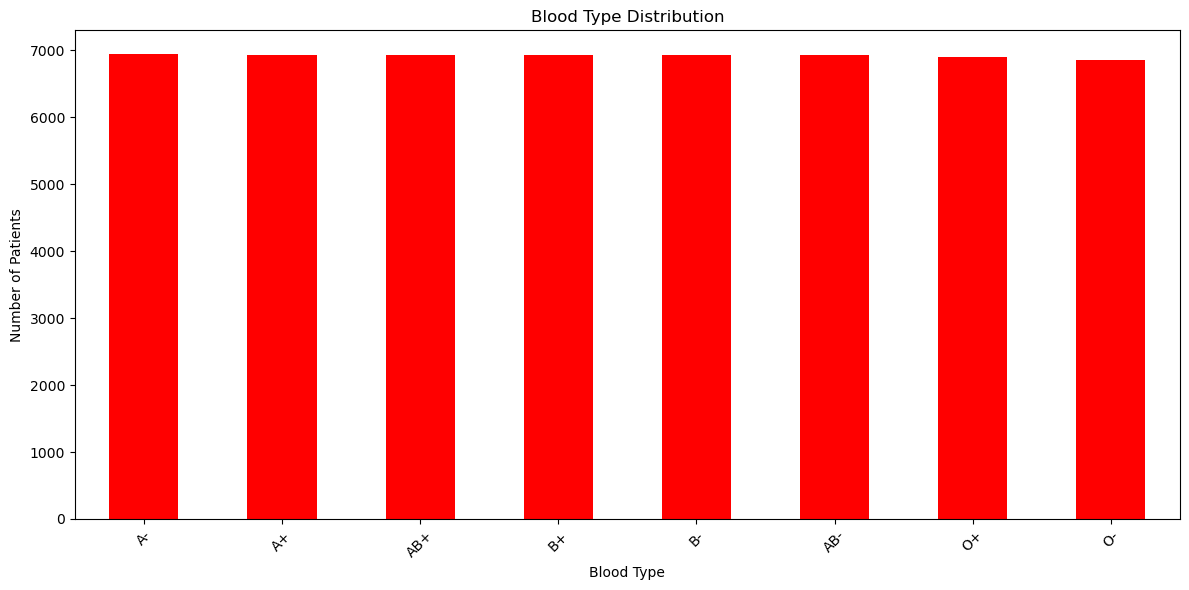

In [30]:
##  Blood Type Distribution (Bar Chart)

plt.figure(figsize=(12,6))
blood_types.plot(kind='bar', color='red')
plt.title('Blood Type Distribution')
plt.xlabel('Blood Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

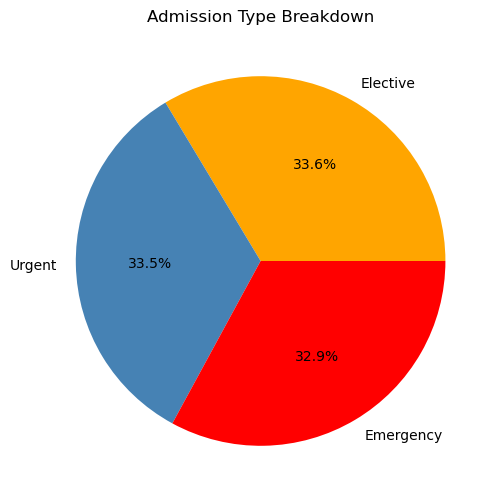

In [31]:
##  Admission Type Breakdown (Pie Chart)

plt.figure(figsize=(8,6))
admission_types.plot(kind='pie', autopct='%1.1f%%', 
colors=['orange', 'steelblue', 'red'])
plt.title('Admission Type Breakdown')
plt.ylabel('')
plt.show()

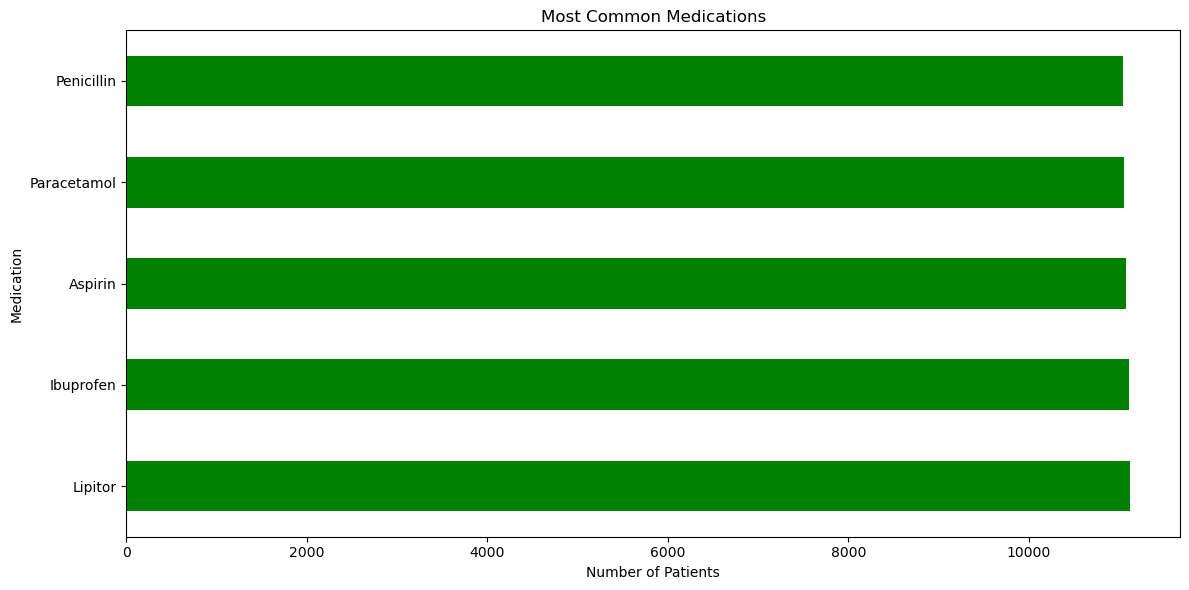

In [32]:
##  Most Common Medications (Bar Chart)

plt.figure(figsize=(12,6))
medications.plot(kind='barh', color='green')
plt.title('Most Common Medications')
plt.xlabel('Number of Patients')
plt.tight_layout()
plt.show()

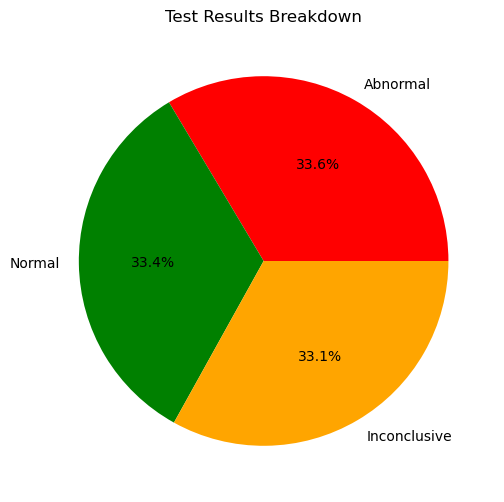

In [33]:
##   Test Results Breakdown (Pie Chart)

plt.figure(figsize=(8,6))
test_results.plot(kind='pie', autopct='%1.1f%%',
colors=['red', 'green', 'orange'])
plt.title('Test Results Breakdown')
plt.ylabel('')
plt.show()

In [34]:
df.to_csv('healthcare_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
